# Task 3: Dataset Preparation and Preprocessing for Deep Learning

## Objective

To prepare an image dataset for deep learning applications through exploratory
data analysis, data quality checking, preprocessing, augmentation, feature
transformation, and train-validation-test splitting.

## Dataset

CIFAR-10 Dataset

The CIFAR-10 dataset contains 60,000 color images of size 32×32 pixels
belonging to 10 different classes.

### Classes

1. Airplane
2. Automobile
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck

## Tasks Performed

- Dataset loading
- Exploratory Data Analysis (EDA)
- Class distribution analysis
- Missing data checking
- Corrupted data checking
- Pixel value analysis
- Image visualization
- Image normalization
- Label encoding
- Train-validation-test splitting
- Image augmentation
- Visualization of augmented images
- Preprocessed dataset preparation
- Documentation of preprocessing steps

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split

import os
import random
import warnings

warnings.filterwarnings("ignore")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("TensorFlow Version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow Version: 2.20.0
Libraries imported successfully!


## Loading the Dataset

The CIFAR-10 dataset is directly available through TensorFlow/Keras.

It contains:

- 50,000 training images
- 10,000 test images
- Image size: 32 × 32 pixels
- 3 RGB color channels
- 10 classes

In [2]:
# Load CIFAR-10 dataset

(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

print("Dataset loaded successfully!")

print("\nTraining Images Shape:", X_train_full.shape)
print("Training Labels Shape:", y_train_full.shape)

print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3301s 19us/step
Dataset loaded successfully!

Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


In [3]:
# CIFAR-10 class names

class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

print("Number of classes:", len(class_names))

for i, name in enumerate(class_names):
    print(i, ":", name)

Number of classes: 10
0 : Airplane
1 : Automobile
2 : Bird
3 : Cat
4 : Deer
5 : Dog
6 : Frog
7 : Horse
8 : Ship
9 : Truck


In [4]:
print("========== DATASET INFORMATION ==========")

print("Total Training Samples:", len(X_train_full))
print("Total Testing Samples:", len(X_test))

print("Image Height:", X_train_full.shape[1])
print("Image Width:", X_train_full.shape[2])
print("Number of Channels:", X_train_full.shape[3])

print("Number of Classes:", len(class_names))

print("\nImage Data Type:", X_train_full.dtype)
print("Minimum Pixel Value:", X_train_full.min())
print("Maximum Pixel Value:", X_train_full.max())

========== DATASET INFORMATION ==========
Total Training Samples: 50000
Total Testing Samples: 10000
Image Height: 32
Image Width: 32
Number of Channels: 3
Number of Classes: 10

Image Data Type: uint8
Minimum Pixel Value: 0
Maximum Pixel Value: 255


## Exploratory Data Analysis

EDA is performed to understand the structure, distribution, quality, and
characteristics of the dataset before preprocessing.

In [5]:
# Convert labels to 1D array

y_train_flat = y_train_full.flatten()
y_test_flat = y_test.flatten()

# Count samples in each class
train_class_counts = np.bincount(y_train_flat)
test_class_counts = np.bincount(y_test_flat)

# Create DataFrame
class_distribution = pd.DataFrame({
    "Class": class_names,
    "Training Samples": train_class_counts,
    "Testing Samples": test_class_counts
})

class_distribution

,Class,Training Samples,Testing Samples
0,Airplane,5000,1000
1,Automobile,5000,1000
2,Bird,5000,1000
3,Cat,5000,1000
4,Deer,5000,1000
5,Dog,5000,1000
6,Frog,5000,1000
7,Horse,5000,1000
8,Ship,5000,1000
9,Truck,5000,1000


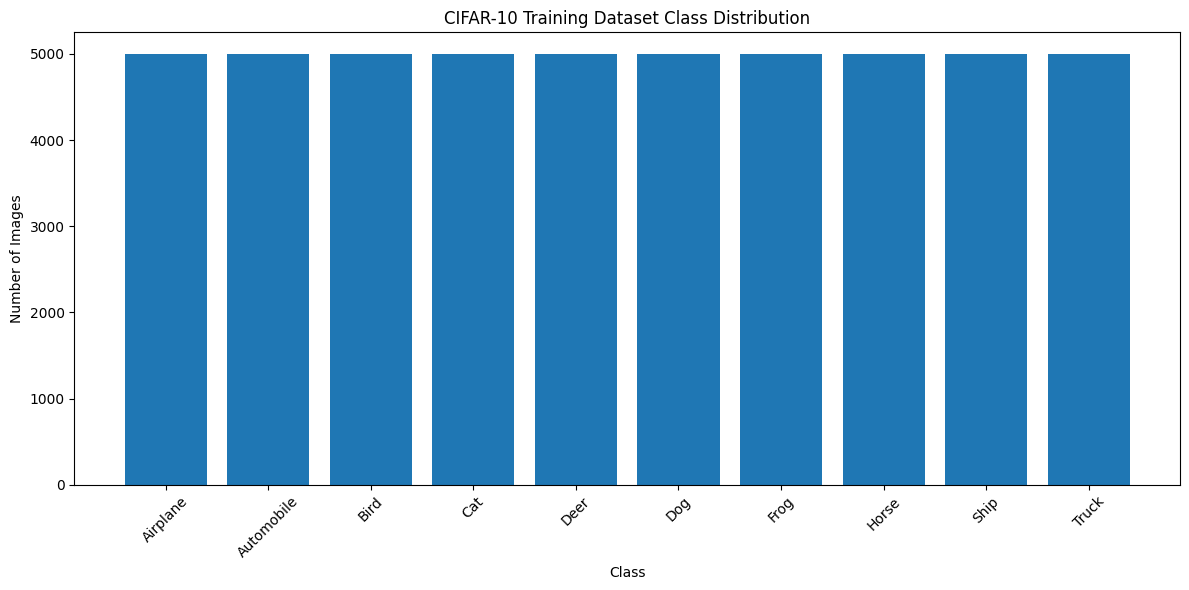

In [6]:
plt.figure(figsize=(12, 6))

plt.bar(class_names, train_class_counts)

plt.title("CIFAR-10 Training Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The class distribution is approximately balanced. Each class contains nearly
the same number of images, which reduces the risk of severe class imbalance
during deep learning model training.

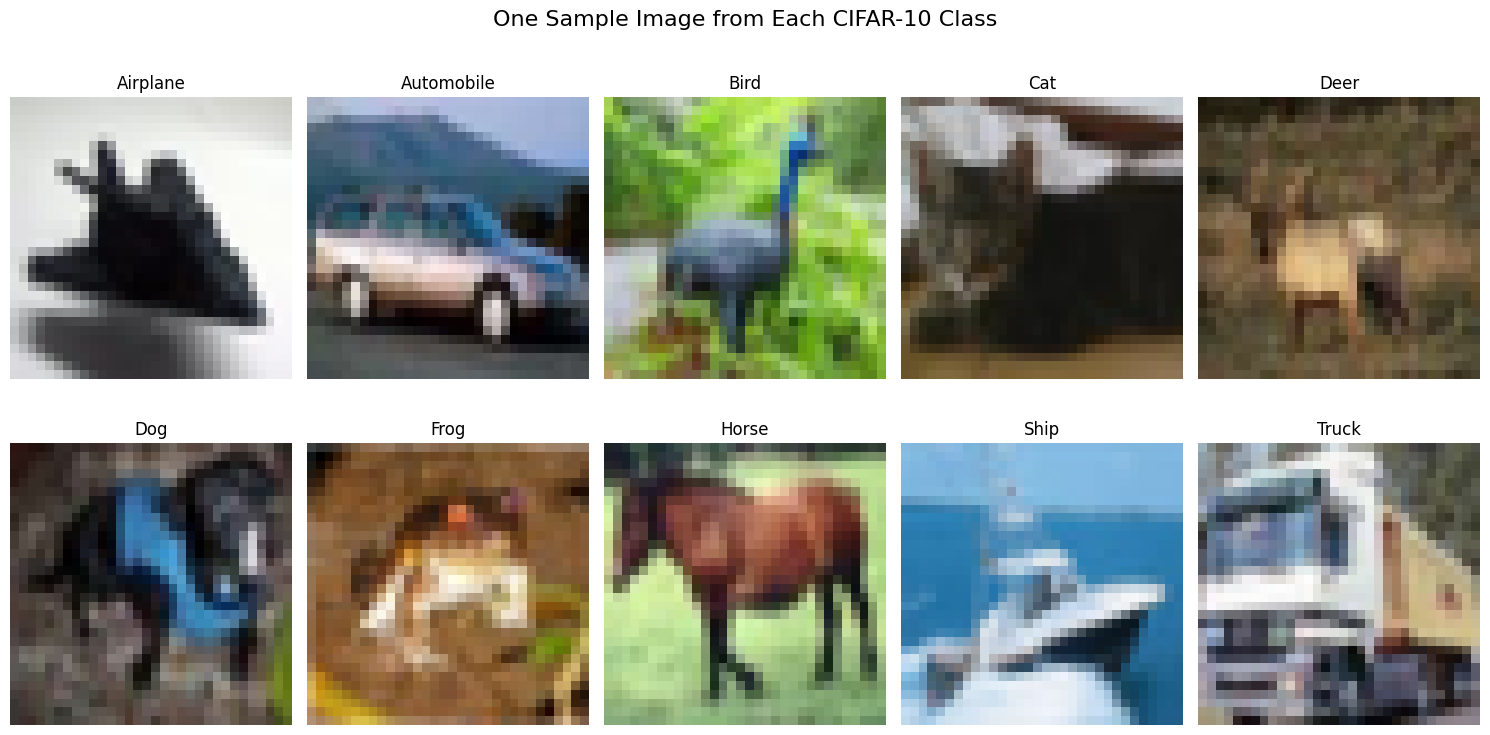

In [7]:
# Display sample images from each class

plt.figure(figsize=(15, 8))

for class_id in range(10):
    # Find first image belonging to the class
    index = np.where(y_train_flat == class_id)[0][0]

    plt.subplot(2, 5, class_id + 1)
    plt.imshow(X_train_full[index])
    plt.title(class_names[class_id])
    plt.axis("off")

plt.suptitle("One Sample Image from Each CIFAR-10 Class", fontsize=16)

plt.tight_layout()
plt.show()

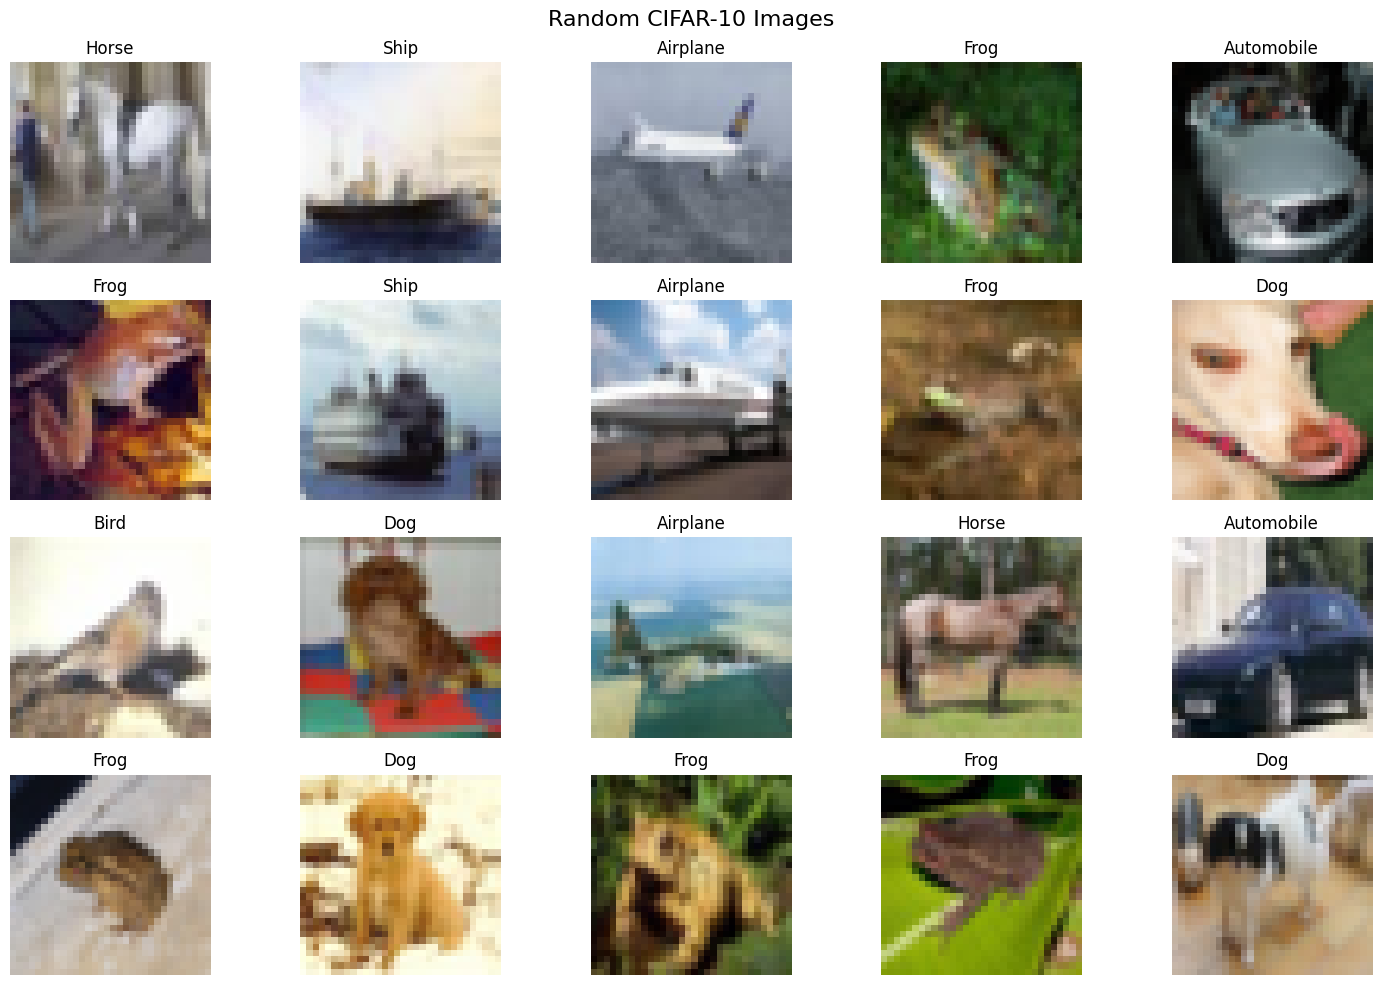

In [8]:
# Display random images

plt.figure(figsize=(15, 10))

random_indices = np.random.choice(len(X_train_full), 20, replace=False)

for i, index in enumerate(random_indices):
    plt.subplot(4, 5, i + 1)

    plt.imshow(X_train_full[index])
    plt.title(class_names[y_train_flat[index]])
    plt.axis("off")

plt.suptitle("Random CIFAR-10 Images", fontsize=16)

plt.tight_layout()
plt.show()

## 10. Missing Data Analysis

Since CIFAR-10 is stored as numerical image arrays, missing values can be
checked using NumPy.

A missing pixel value would normally appear as NaN.

In [9]:
print("Missing values in training images:", np.isnan(X_train_full).sum())
print("Missing values in testing images:", np.isnan(X_test).sum())

print("Missing values in training labels:", np.isnan(y_train_full).sum())
print("Missing values in testing labels:", np.isnan(y_test).sum())

Missing values in training images: 0
Missing values in testing images: 0
Missing values in training labels: 0
Missing values in testing labels: 0


### Observation

No missing values were detected in the CIFAR-10 image arrays or labels.
Therefore, no missing-value imputation was required.

In [10]:
print("Infinite values in training images:",
      np.isinf(X_train_full).sum())

print("Infinite values in testing images:",
      np.isinf(X_test).sum())

Infinite values in training images: 0
Infinite values in testing images: 0


In [11]:
# Check duplicate images in a manageable sample

sample_size = 10000

sample_images = X_train_full[:sample_size]

# Convert images to flattened representation
flattened_images = sample_images.reshape(sample_size, -1)

# Count unique images
unique_images = np.unique(flattened_images, axis=0)

print("Images checked:", sample_size)
print("Unique images:", len(unique_images))
print("Potential duplicate images:", sample_size - len(unique_images))

Images checked: 10000
Unique images: 10000
Potential duplicate images: 0


### Observation

A sample of the training images was checked for exact duplicate images.
The duplicate check is performed on the pixel representation of images.

In [12]:
# Check image dimensions

image_shapes = {}

for image in X_train_full[:1000]:
    shape = image.shape

    if shape not in image_shapes:
        image_shapes[shape] = 0

    image_shapes[shape] += 1

print("Image shape distribution:")
for shape, count in image_shapes.items():
    print(shape, ":", count)

Image shape distribution:
(32, 32, 3) : 1000


### Observation

All CIFAR-10 images have the same dimensions of 32×32 pixels with 3 RGB
channels. Therefore, resizing is not required.

In [13]:
# Analyze pixel values

pixel_values = X_train_full.flatten()

print("Minimum pixel value:", pixel_values.min())
print("Maximum pixel value:", pixel_values.max())
print("Mean pixel value:", pixel_values.mean())
print("Standard deviation:", pixel_values.std())

Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 120.70756512369792
Standard deviation: 64.15007589112135


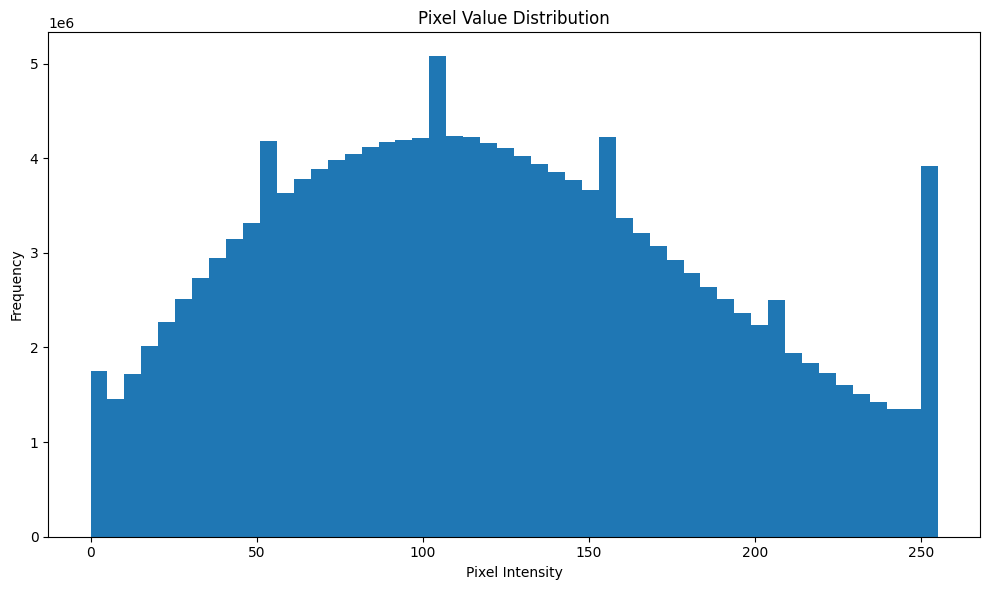

In [14]:
plt.figure(figsize=(10, 6))

plt.hist(
    pixel_values,
    bins=50
)

plt.title("Pixel Value Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [15]:
# Calculate mean RGB values

mean_red = X_train_full[:, :, :, 0].mean()
mean_green = X_train_full[:, :, :, 1].mean()
mean_blue = X_train_full[:, :, :, 2].mean()

print("Mean Red Channel:", mean_red)
print("Mean Green Channel:", mean_green)
print("Mean Blue Channel:", mean_blue)

Mean Red Channel: 125.306918046875
Mean Green Channel: 122.950394140625
Mean Blue Channel: 113.86538318359375


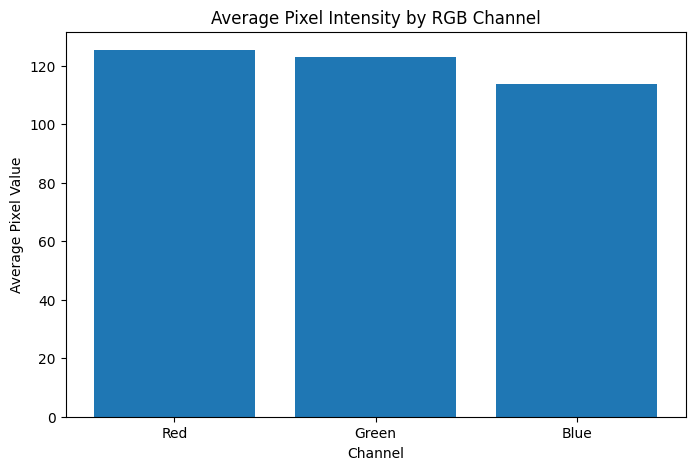

In [16]:
channel_means = [mean_red, mean_green, mean_blue]
channels = ["Red", "Green", "Blue"]

plt.figure(figsize=(8, 5))

plt.bar(channels, channel_means)

plt.title("Average Pixel Intensity by RGB Channel")
plt.xlabel("Channel")
plt.ylabel("Average Pixel Value")

plt.show()

## 17. Train-Validation-Test Split

The original CIFAR-10 training dataset is divided into:

- 90% Training
- 10% Validation

The official CIFAR-10 test set is kept completely separate.

Final dataset:

Training: 45,000 images
Validation: 5,000 images
Testing: 10,000 images

In [17]:
# Split original training data into training and validation sets

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=42,
    stratify=y_train_full
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (45000, 32, 32, 3) (45000, 1)
Validation set: (5000, 32, 32, 3) (5000, 1)
Test set: (10000, 32, 32, 3) (10000, 1)


In [18]:
train_counts = np.bincount(y_train.flatten())
val_counts = np.bincount(y_val.flatten())
test_counts = np.bincount(y_test.flatten())

split_distribution = pd.DataFrame({
    "Class": class_names,
    "Train": train_counts,
    "Validation": val_counts,
    "Test": test_counts
})

split_distribution

,Class,Train,Validation,Test
0,Airplane,4500,500,1000
1,Automobile,4500,500,1000
2,Bird,4500,500,1000
3,Cat,4500,500,1000
4,Deer,4500,500,1000
5,Dog,4500,500,1000
6,Frog,4500,500,1000
7,Horse,4500,500,1000
8,Ship,4500,500,1000
9,Truck,4500,500,1000


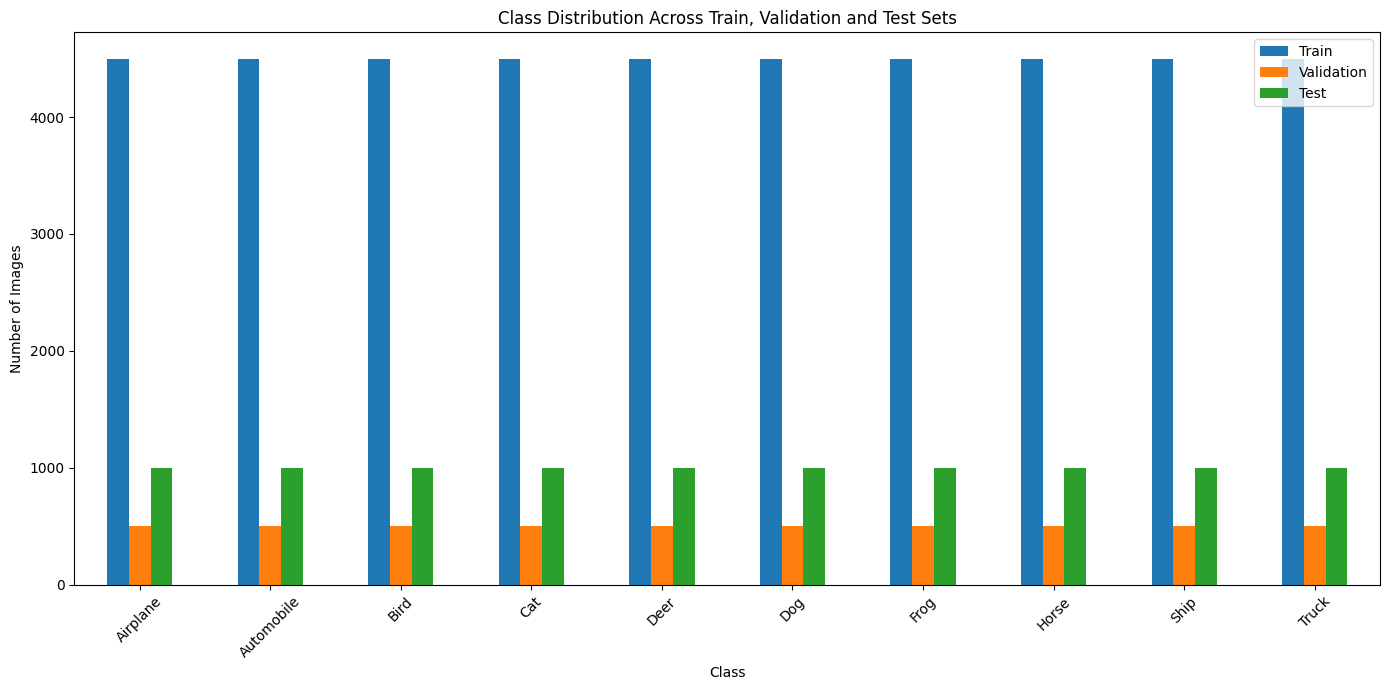

In [19]:
split_distribution_plot = split_distribution.set_index("Class")

split_distribution_plot.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title("Class Distribution Across Train, Validation and Test Sets")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Currently, pixels range from:

0 to 255

Deep learning models generally perform better when input values are scaled.

We will normalize them to:

0 to 1

In [20]:
# Convert image arrays to float32

X_train = X_train.astype("float32")
X_val = X_val.astype("float32")
X_test = X_test.astype("float32")

# Normalize pixel values to 0-1

X_train_normalized = X_train / 255.0
X_val_normalized = X_val / 255.0
X_test_normalized = X_test / 255.0

print("Original pixel range:")
print(X_train.min(), "to", X_train.max())

print("\nNormalized pixel range:")
print(X_train_normalized.min(), "to", X_train_normalized.max())

Original pixel range:
0.0 to 255.0

Normalized pixel range:
0.0 to 1.0


In [21]:
#Verify Normalization
print("Training data:")
print("Minimum:", X_train_normalized.min())
print("Maximum:", X_train_normalized.max())
print("Mean:", X_train_normalized.mean())
print("Standard Deviation:", X_train_normalized.std())

print("\nValidation data:")
print("Minimum:", X_val_normalized.min())
print("Maximum:", X_val_normalized.max())

print("\nTesting data:")
print("Minimum:", X_test_normalized.min())
print("Maximum:", X_test_normalized.max())

Training data:
Minimum: 0.0
Maximum: 1.0
Mean: 0.4732333
Standard Deviation: 0.2514992

Validation data:
Minimum: 0.0
Maximum: 1.0

Testing data:
Minimum: 0.0
Maximum: 1.0


##Label Encoding

For deep learning classification, labels can be represented using one-hot encoding.

In [22]:
# One-hot encode labels

y_train_encoded = to_categorical(y_train, num_classes=10)
y_val_encoded = to_categorical(y_val, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

print("Original label shape:", y_train.shape)
print("Encoded label shape:", y_train_encoded.shape)

print("\nExample:")
print("Original:", y_train[0])
print("Encoded:", y_train_encoded[0])

Original label shape: (45000, 1)
Encoded label shape: (45000, 10)

Example:
Original: [1]
Encoded: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


## 23. Image Augmentation

Image augmentation artificially creates variations of existing training
images. This can improve model generalization and reduce overfitting.

The following transformations are applied:

- Random rotation
- Horizontal translation
- Vertical translation
- Horizontal flipping
- Zoom

In [23]:
# Create ImageDataGenerator for augmentation

augmentation_generator = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    zoom_range=0.10
)

print("Image augmentation generator created successfully!")

Image augmentation generator created successfully!


##Visualize Augmented Images

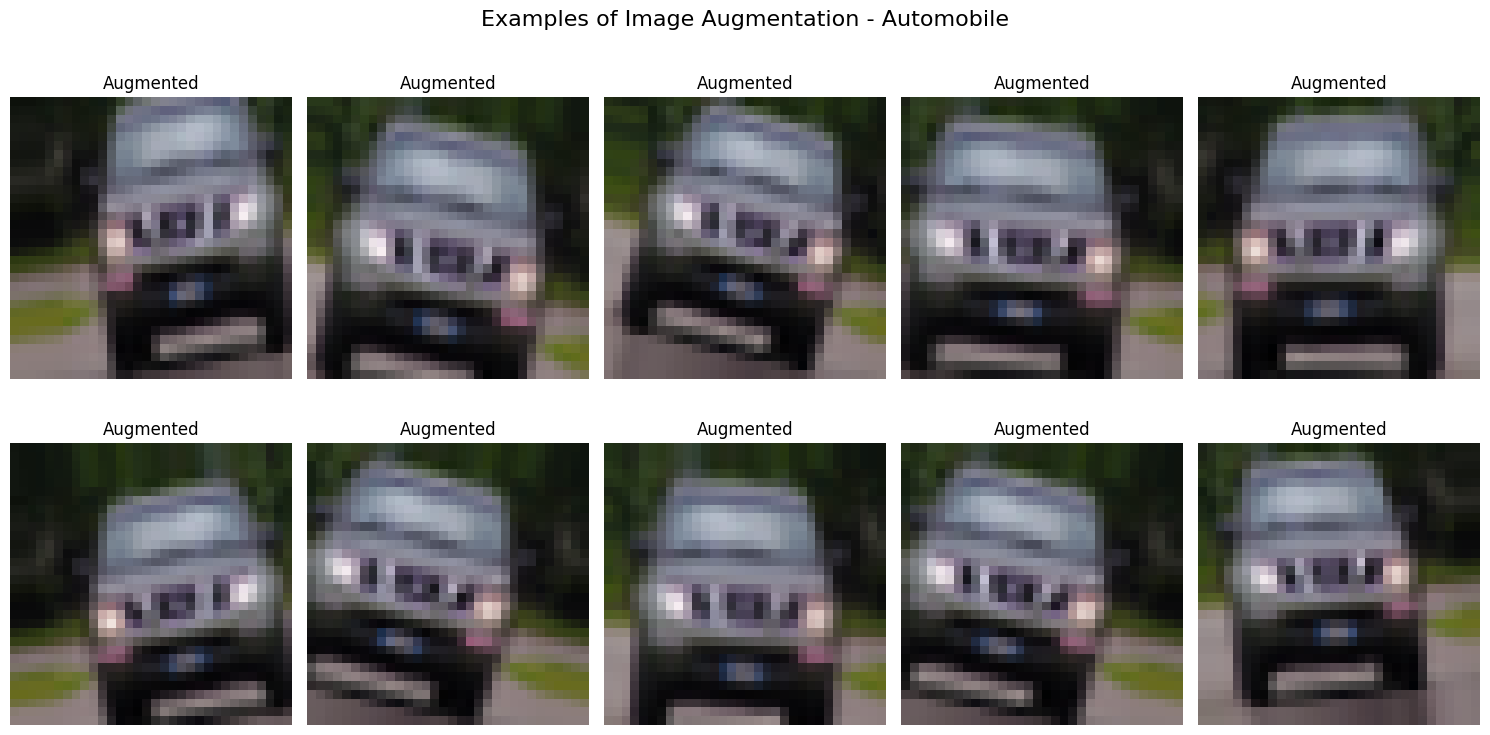

In [24]:
# Select one image

sample_image = X_train_normalized[0]
sample_label = y_train.flatten()[0]

# Reshape image to create a batch
sample_image_batch = np.expand_dims(sample_image, axis=0)

# Generate augmented images
augmented_images = augmentation_generator.flow(
    sample_image_batch,
    batch_size=1,
    shuffle=False
)

plt.figure(figsize=(15, 8))

for i in range(10):

    augmented_image = next(augmented_images)[0]

    plt.subplot(2, 5, i + 1)
    plt.imshow(augmented_image)
    plt.title("Augmented")
    plt.axis("off")

plt.suptitle(
    "Examples of Image Augmentation - " + class_names[sample_label],
    fontsize=16
)

plt.tight_layout()
plt.show()

##Original vs Augmented Image

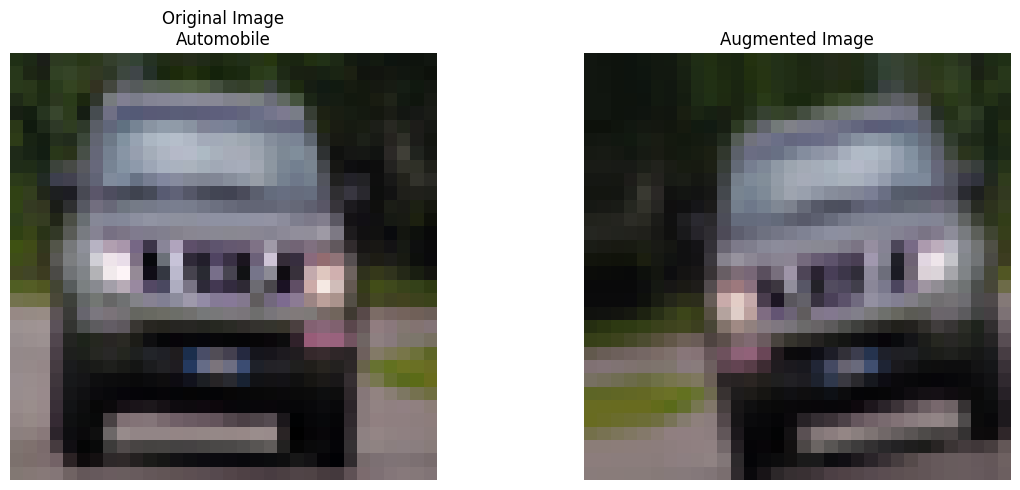

In [25]:
plt.figure(figsize=(12, 5))

# Original image
plt.subplot(1, 2, 1)

plt.imshow(X_train_normalized[0])

plt.title(
    "Original Image\n" + class_names[y_train.flatten()[0]]
)

plt.axis("off")

# Augmented image
augmented_image = next(
    augmentation_generator.flow(
        np.expand_dims(X_train_normalized[0], axis=0),
        batch_size=1,
        shuffle=False
    )
)[0]

plt.subplot(1, 2, 2)

plt.imshow(augmented_image)

plt.title("Augmented Image")
plt.axis("off")

plt.tight_layout()
plt.show()

##Before vs After Preprocessing

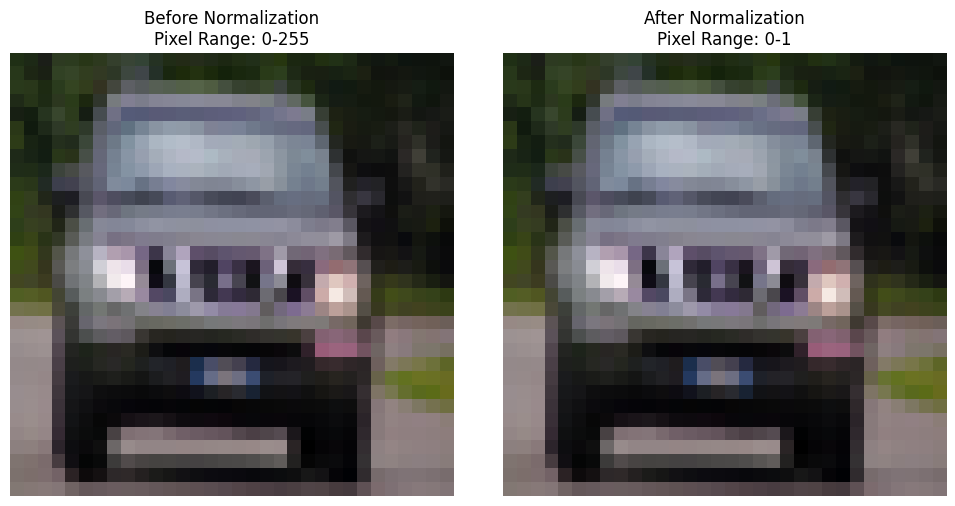

In [26]:
plt.figure(figsize=(10, 5))

# Original
plt.subplot(1, 2, 1)

plt.imshow(X_train[0].astype("uint8"))

plt.title(
    "Before Normalization\nPixel Range: 0-255"
)

plt.axis("off")

# Normalized
plt.subplot(1, 2, 2)

plt.imshow(X_train_normalized[0])

plt.title(
    "After Normalization\nPixel Range: 0-1"
)

plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
print("========== FINAL DATASET SHAPES ==========")

print("Training Images:", X_train_normalized.shape)
print("Training Labels:", y_train_encoded.shape)

print("Validation Images:", X_val_normalized.shape)
print("Validation Labels:", y_val_encoded.shape)

print("Testing Images:", X_test_normalized.shape)
print("Testing Labels:", y_test_encoded.shape)

========== FINAL DATASET SHAPES ==========
Training Images: (45000, 32, 32, 3)
Training Labels: (45000, 10)
Validation Images: (5000, 32, 32, 3)
Validation Labels: (5000, 10)
Testing Images: (10000, 32, 32, 3)
Testing Labels: (10000, 10)


In [28]:
data_quality_summary = {
    "Missing Values": np.isnan(X_train_normalized).sum(),
    "Infinite Values": np.isinf(X_train_normalized).sum(),
    "Image Height": X_train_normalized.shape[1],
    "Image Width": X_train_normalized.shape[2],
    "Channels": X_train_normalized.shape[3],
    "Number of Classes": len(class_names),
    "Training Samples": len(X_train_normalized),
    "Validation Samples": len(X_val_normalized),
    "Testing Samples": len(X_test_normalized),
    "Minimum Pixel Value": X_train_normalized.min(),
    "Maximum Pixel Value": X_train_normalized.max()
}

quality_df = pd.DataFrame(
    list(data_quality_summary.items()),
    columns=["Metric", "Value"]
)

quality_df

,Metric,Value
0,Missing Values,0.0
1,Infinite Values,0.0
2,Image Height,32.0
3,Image Width,32.0
4,Channels,3.0
5,Number of Classes,10.0
6,Training Samples,45000.0
7,Validation Samples,5000.0
8,Testing Samples,10000.0
9,Minimum Pixel Value,0.0


In [29]:
# Generate Final EDA Report
print("=" * 60)
print("FINAL EDA AND PREPROCESSING REPORT")
print("=" * 60)

print("\n1. DATASET")
print("Dataset: CIFAR-10")

print("\n2. ORIGINAL DATASET")
print("Training samples:", len(X_train_full))
print("Testing samples:", len(X_test))

print("\n3. FINAL SPLIT")
print("Training:", len(X_train))
print("Validation:", len(X_val))
print("Testing:", len(X_test))

print("\n4. IMAGE INFORMATION")
print("Image size: 32 x 32")
print("Channels: RGB")
print("Classes:", len(class_names))

print("\n5. DATA QUALITY")
print("Missing values:", np.isnan(X_train_full).sum())
print("Infinite values:", np.isinf(X_train_full).sum())

print("\n6. PREPROCESSING")
print("Pixel normalization: 0-255 → 0-1")
print("Label encoding: One-hot encoding")

print("\n7. AUGMENTATION")
print("Rotation: 15 degrees")
print("Width shift: 10%")
print("Height shift: 10%")
print("Horizontal flip: Enabled")
print("Zoom: 10%")

print("\n8. FINAL PIXEL RANGE")
print("Minimum:", X_train_normalized.min())
print("Maximum:", X_train_normalized.max())

print("\n" + "=" * 60)
print("PREPROCESSING COMPLETED SUCCESSFULLY")
print("=" * 60)

FINAL EDA AND PREPROCESSING REPORT

1. DATASET
Dataset: CIFAR-10

2. ORIGINAL DATASET
Training samples: 50000
Testing samples: 10000

3. FINAL SPLIT
Training: 45000
Validation: 5000
Testing: 10000

4. IMAGE INFORMATION
Image size: 32 x 32
Channels: RGB
Classes: 10

5. DATA QUALITY
Missing values: 0
Infinite values: 0

6. PREPROCESSING
Pixel normalization: 0-255 → 0-1
Label encoding: One-hot encoding

7. AUGMENTATION
Rotation: 15 degrees
Width shift: 10%
Height shift: 10%
Horizontal flip: Enabled
Zoom: 10%

8. FINAL PIXEL RANGE
Minimum: 0.0
Maximum: 1.0

PREPROCESSING COMPLETED SUCCESSFULLY


# Observations and Results

## Observations

1. The CIFAR-10 dataset contains 60,000 RGB images belonging to 10 classes.

2. The images have a fixed size of 32×32 pixels with three RGB channels.

3. The dataset is approximately balanced, with similar numbers of samples
   across all ten classes.

4. No missing values were detected in the dataset.

5. No infinite pixel values were detected.

6. Image dimensions were consistent across the dataset, so resizing was not
   required.

7. Pixel values originally ranged from 0 to 255.

8. Pixel normalization transformed the values into the range 0 to 1, making
   the data more suitable for deep learning models.

9. The original training data was divided into training and validation sets
   while keeping the official test set separate.

10. One-hot encoding was applied to the class labels.

11. Image augmentation techniques including rotation, shifting, horizontal
    flipping and zooming were implemented.

12. Visualization confirmed that the augmentation pipeline produces different
    variations of the original images.

## Conclusion

The CIFAR-10 dataset was successfully prepared for deep learning applications.
EDA was performed to understand the dataset, data quality checks were conducted,
and preprocessing techniques were applied.

The final dataset contains separate training, validation and testing sets.
Images were normalized and labels were one-hot encoded. Image augmentation was
also implemented to generate additional variations of training images and
improve the robustness of future deep learning models.

Therefore, the dataset is ready to be used for CNN or transfer-learning based
image classification.

In [30]:
# Save preprocessed data

np.savez_compressed(
    "cifar10_preprocessed.npz",
    X_train=X_train_normalized,
    y_train=y_train_encoded,
    X_val=X_val_normalized,
    y_val=y_val_encoded,
    X_test=X_test_normalized,
    y_test=y_test_encoded
)

print("Preprocessed dataset saved successfully!")

Preprocessed dataset saved successfully!


In [32]:
import os

file_path = "cifar10_preprocessed.npz"

if os.path.exists(file_path):
    file_size_mb = os.path.getsize(file_path) / (1024 * 1024)

    print("File:", file_path)
    print("Size: {:.2f} MB".format(file_size_mb))
    print("Status: Successfully created")

File: cifar10_preprocessed.npz
Size: 228.38 MB
Status: Successfully created
